This dataset is used to classify sonar signals that are bounced off either metal cylinders (mines) or rocks based on signal strength across different frequencies. It is a classic binary classification problem and is widely used for evaluating machine learning models in the context of sound-based signal processing.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , classification_report

In [ ]:
pd.set_option("display.max_columns" , None)

In [ ]:
df = pd.read_csv("sonar.csv" , header = None)

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [ ]:
df.shape

(208, 61)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       208 non-null    float64
 1   1       208 non-null    float64
 2   2       208 non-null    float64
 3   3       208 non-null    float64
 4   4       208 non-null    float64
 5   5       208 non-null    float64
 6   6       208 non-null    float64
 7   7       208 non-null    float64
 8   8       208 non-null    float64
 9   9       208 non-null    float64
 10  10      208 non-null    float64
 11  11      208 non-null    float64
 12  12      208 non-null    float64
 13  13      208 non-null    float64
 14  14      208 non-null    float64
 15  15      208 non-null    float64
 16  16      208 non-null    float64
 17  17      208 non-null    float64
 18  18      208 non-null    float64
 19  19      208 non-null    float64
 20  20      208 non-null    float64
 21  21      208 non-null    float64
 22  22

In [ ]:
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
56,0
57,0
58,0
59,0


In [ ]:
df.columns

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60],
      dtype='int64')

In [ ]:
for col in df.columns:
  print(df[col].value_counts())

0
0.0201    5
0.0094    3
0.0131    3
0.0100    3
0.0209    3
         ..
0.0272    1
0.0187    1
0.0323    1
0.0522    1
0.0303    1
Name: count, Length: 177, dtype: int64
1
0.0523    2
0.0582    2
0.0453    2
0.0086    2
0.0309    2
         ..
0.0387    1
0.0258    1
0.0346    1
0.0101    1
0.0353    1
Name: count, Length: 182, dtype: int64
2
0.0277    2
0.0623    2
0.0347    2
0.0842    2
0.0136    2
         ..
0.0329    1
0.0488    1
0.0168    1
0.0180    1
0.0490    1
Name: count, Length: 190, dtype: int64
3
0.0108    3
0.0608    3
0.0250    2
0.0489    2
0.0394    2
         ..
0.0570    1
0.0848    1
0.0177    1
0.0564    1
0.0292    1
Name: count, Length: 181, dtype: int64
4
0.1158    2
0.0305    2
0.0647    2
0.0597    2
0.1615    2
         ..
0.0393    1
0.0760    1
0.0351    1
0.0167    1
0.0214    1
Name: count, Length: 193, dtype: int64
5
0.0438    2
0.0526    2
0.0771    2
0.0284    2
0.0690    2
         ..
0.1630    1
0.0958    1
0.1171    1
0.1354    1
0.0338    1
N

In [ ]:
df[60].value_counts(normalize = True)

,proportion
60,
M,0.533654
R,0.466346


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [ ]:
df[60] = encoder.fit_transform(df[60])

Rock = 1 and Mine = 0


In [ ]:
df[60]

,60
0,1
1,1
2,1
3,1
4,1
...,...
203,0
204,0
205,0
206,0


In [ ]:
df.duplicated().sum()

np.int64(0)

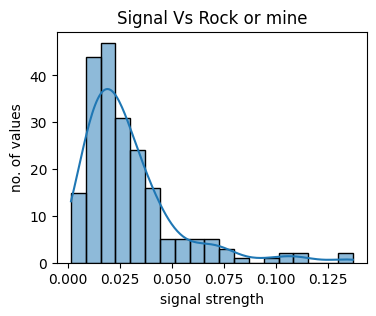

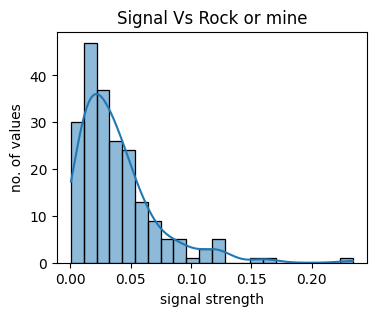

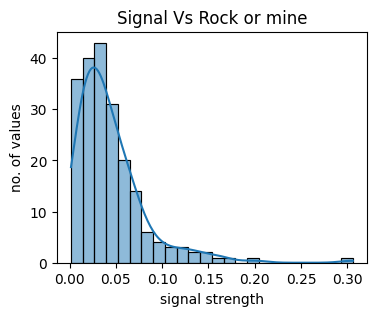

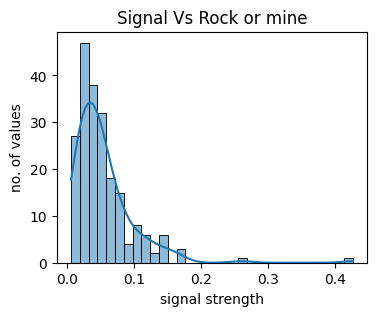

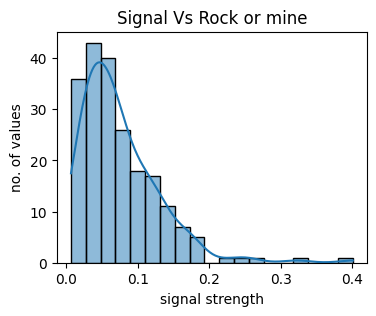

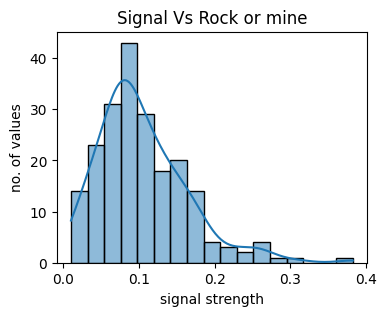

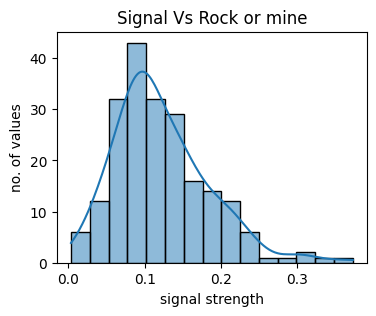

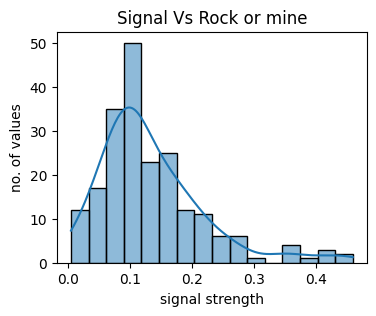

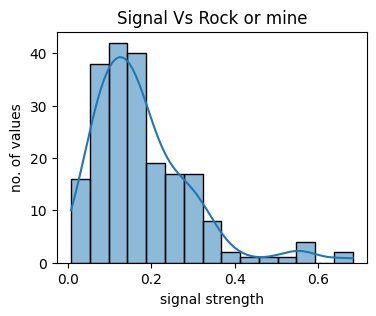

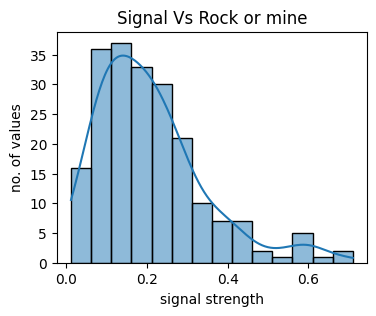

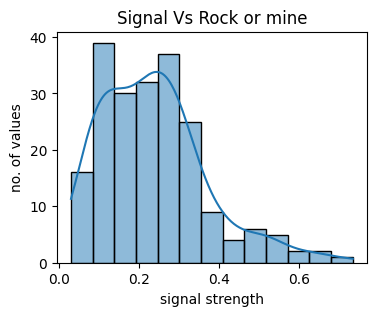

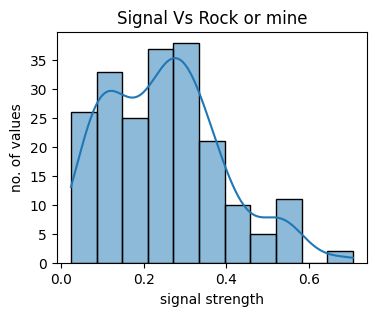

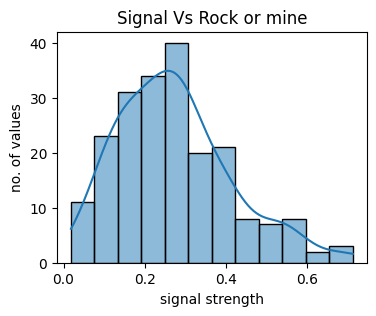

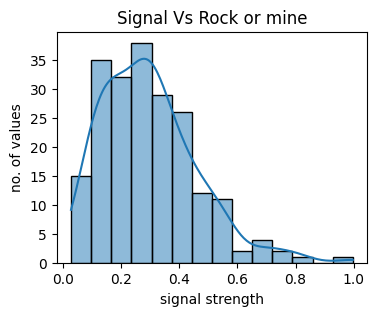

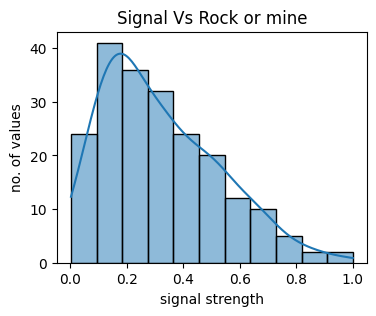

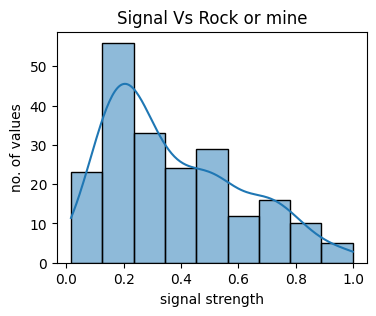

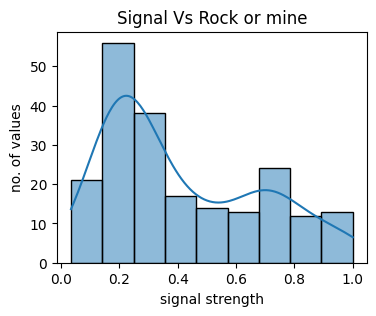

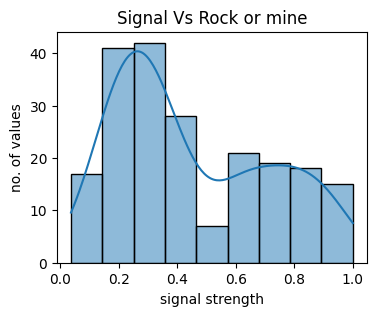

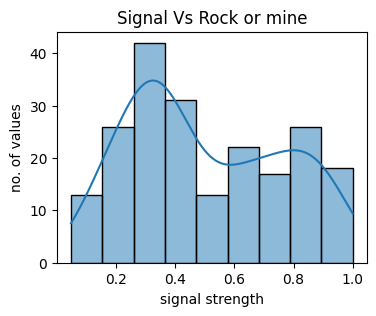

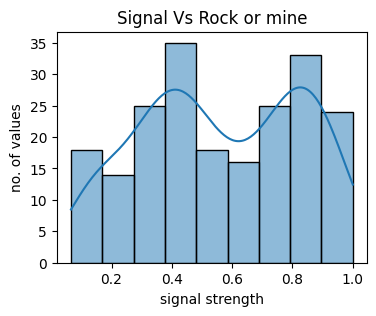

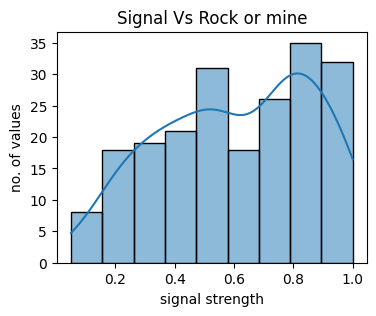

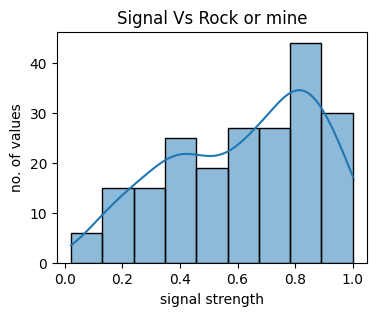

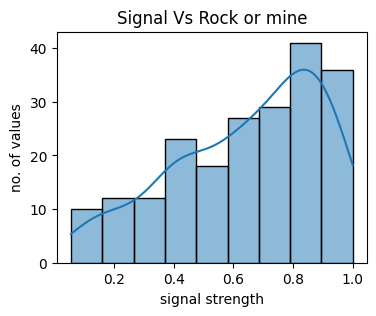

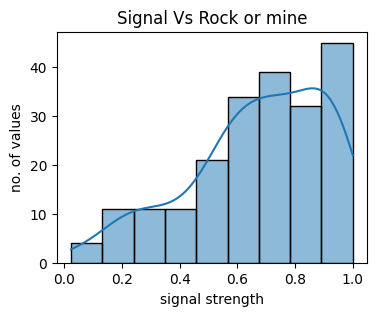

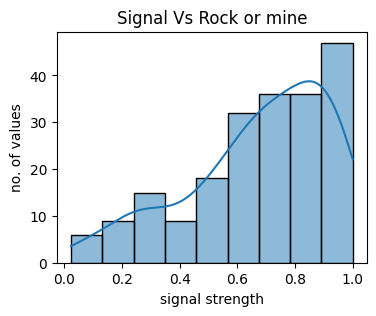

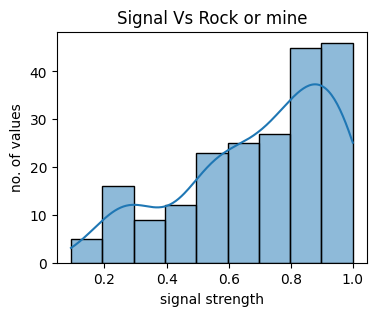

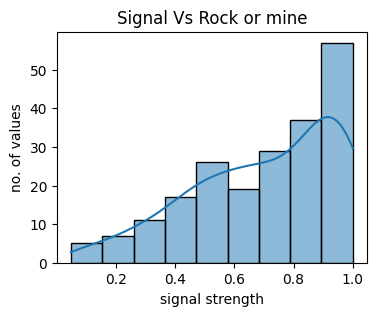

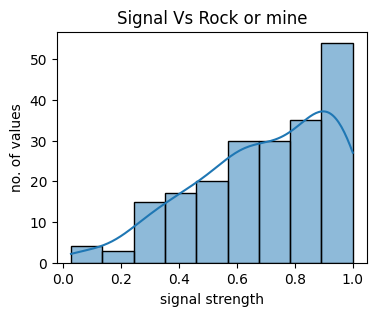

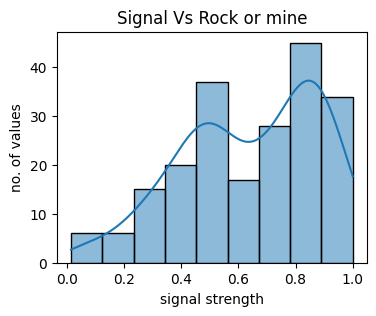

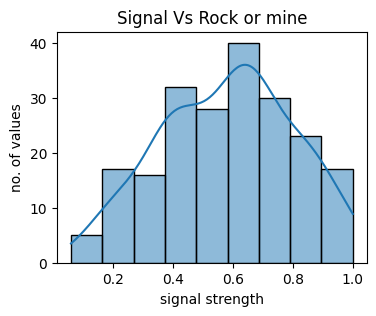

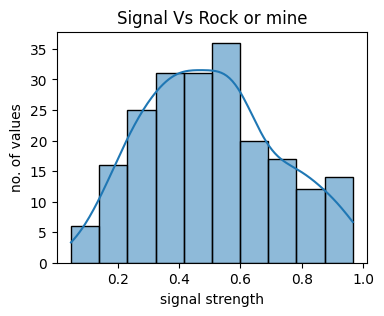

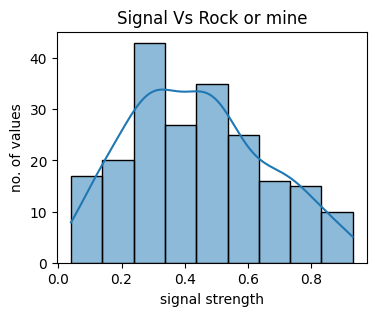

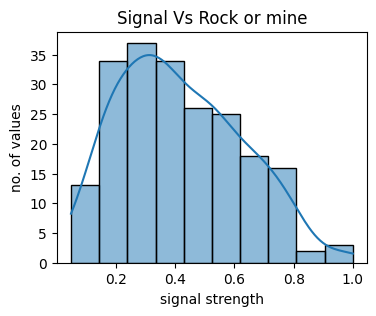

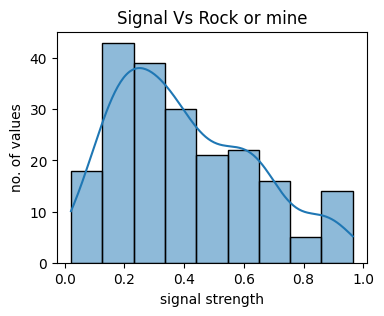

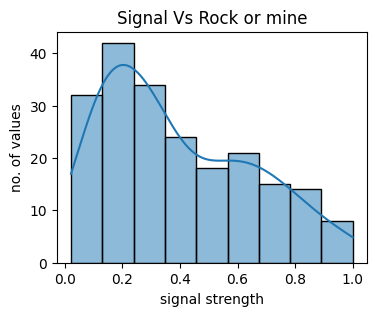

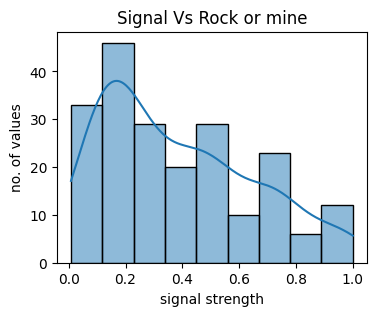

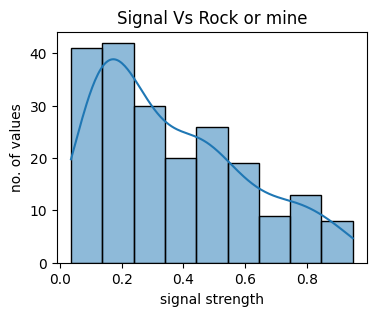

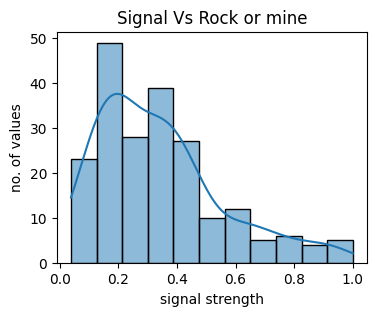

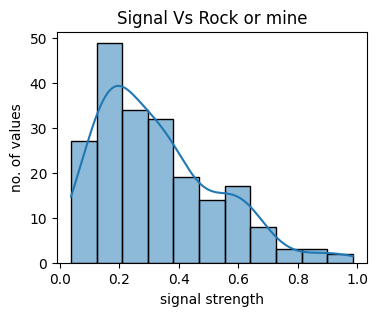

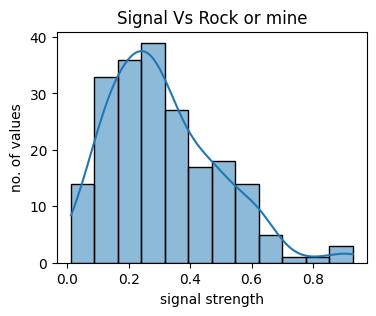

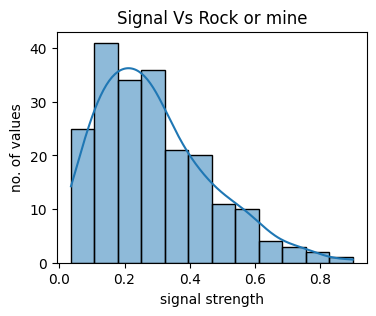

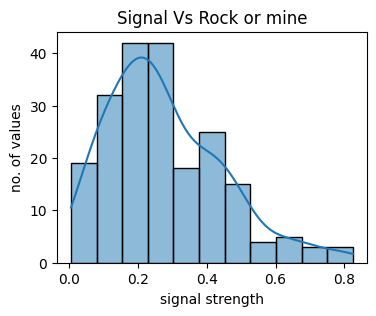

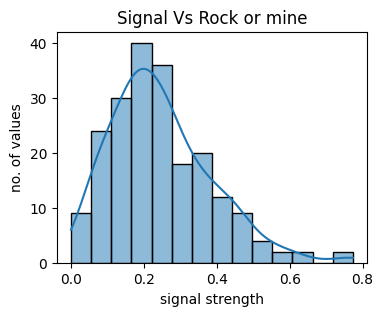

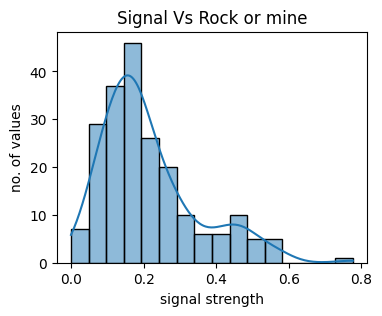

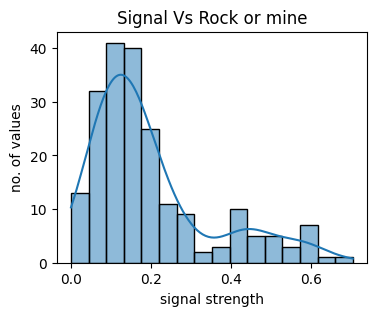

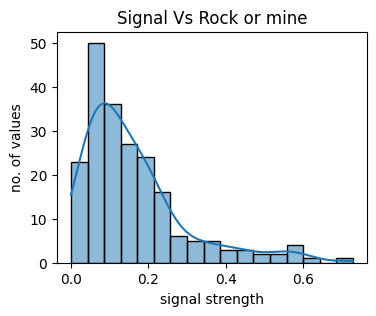

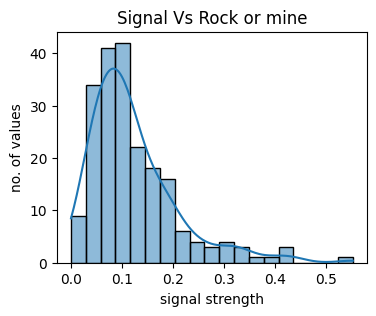

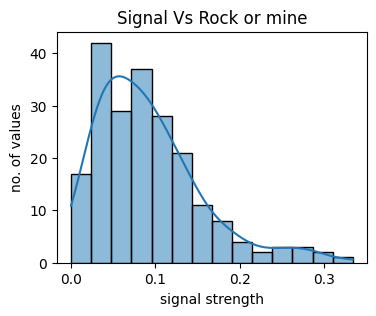

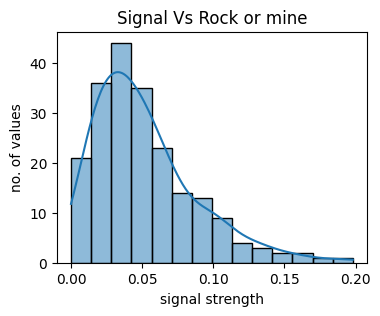

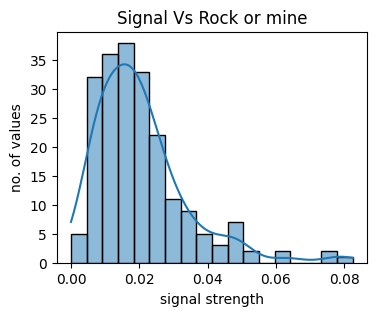

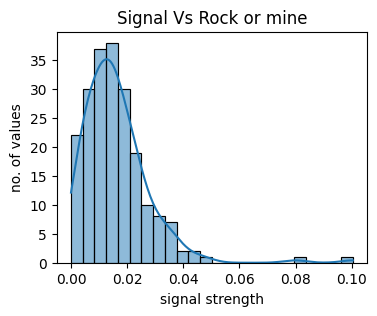

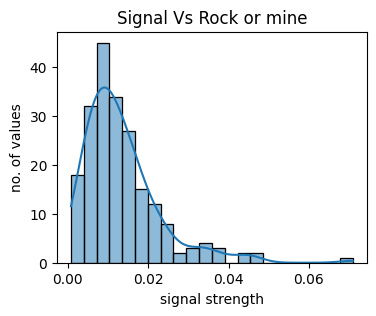

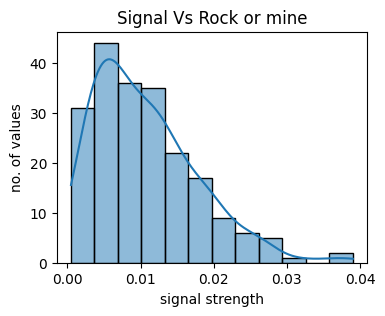

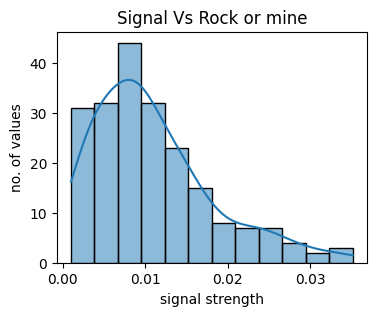

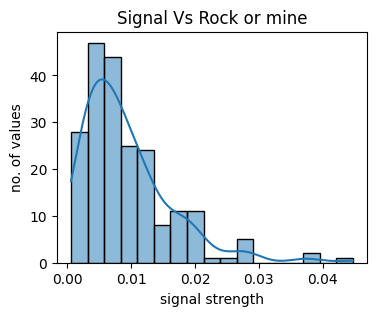

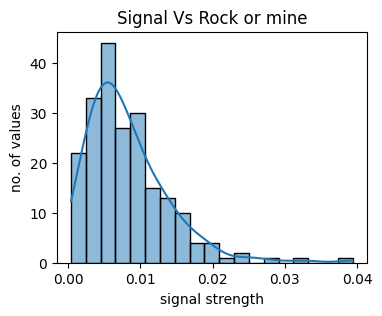

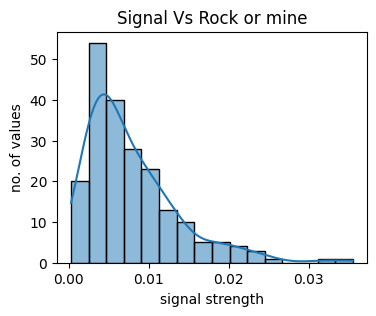

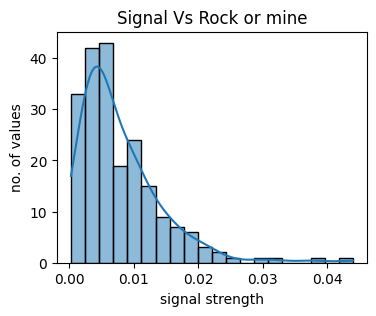

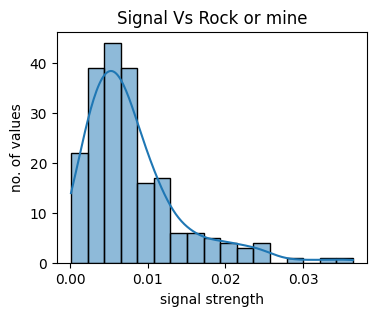

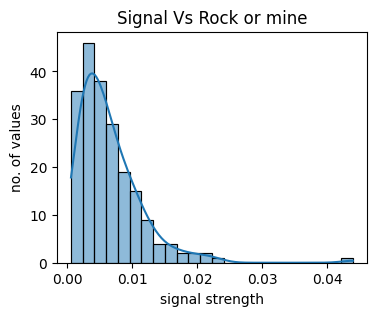

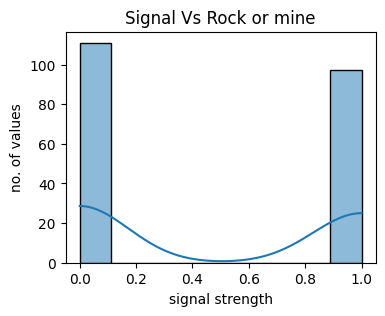

In [ ]:
# for col in df.columns:
#   plt.figure(figsize = (4 , 3))
#   sns.histplot(df[col] , kde = True)
#   plt.title("Signal Vs Rock or mine")
#   plt.xlabel("signal strength")
#   plt.ylabel("no. of values")
#   plt.show()

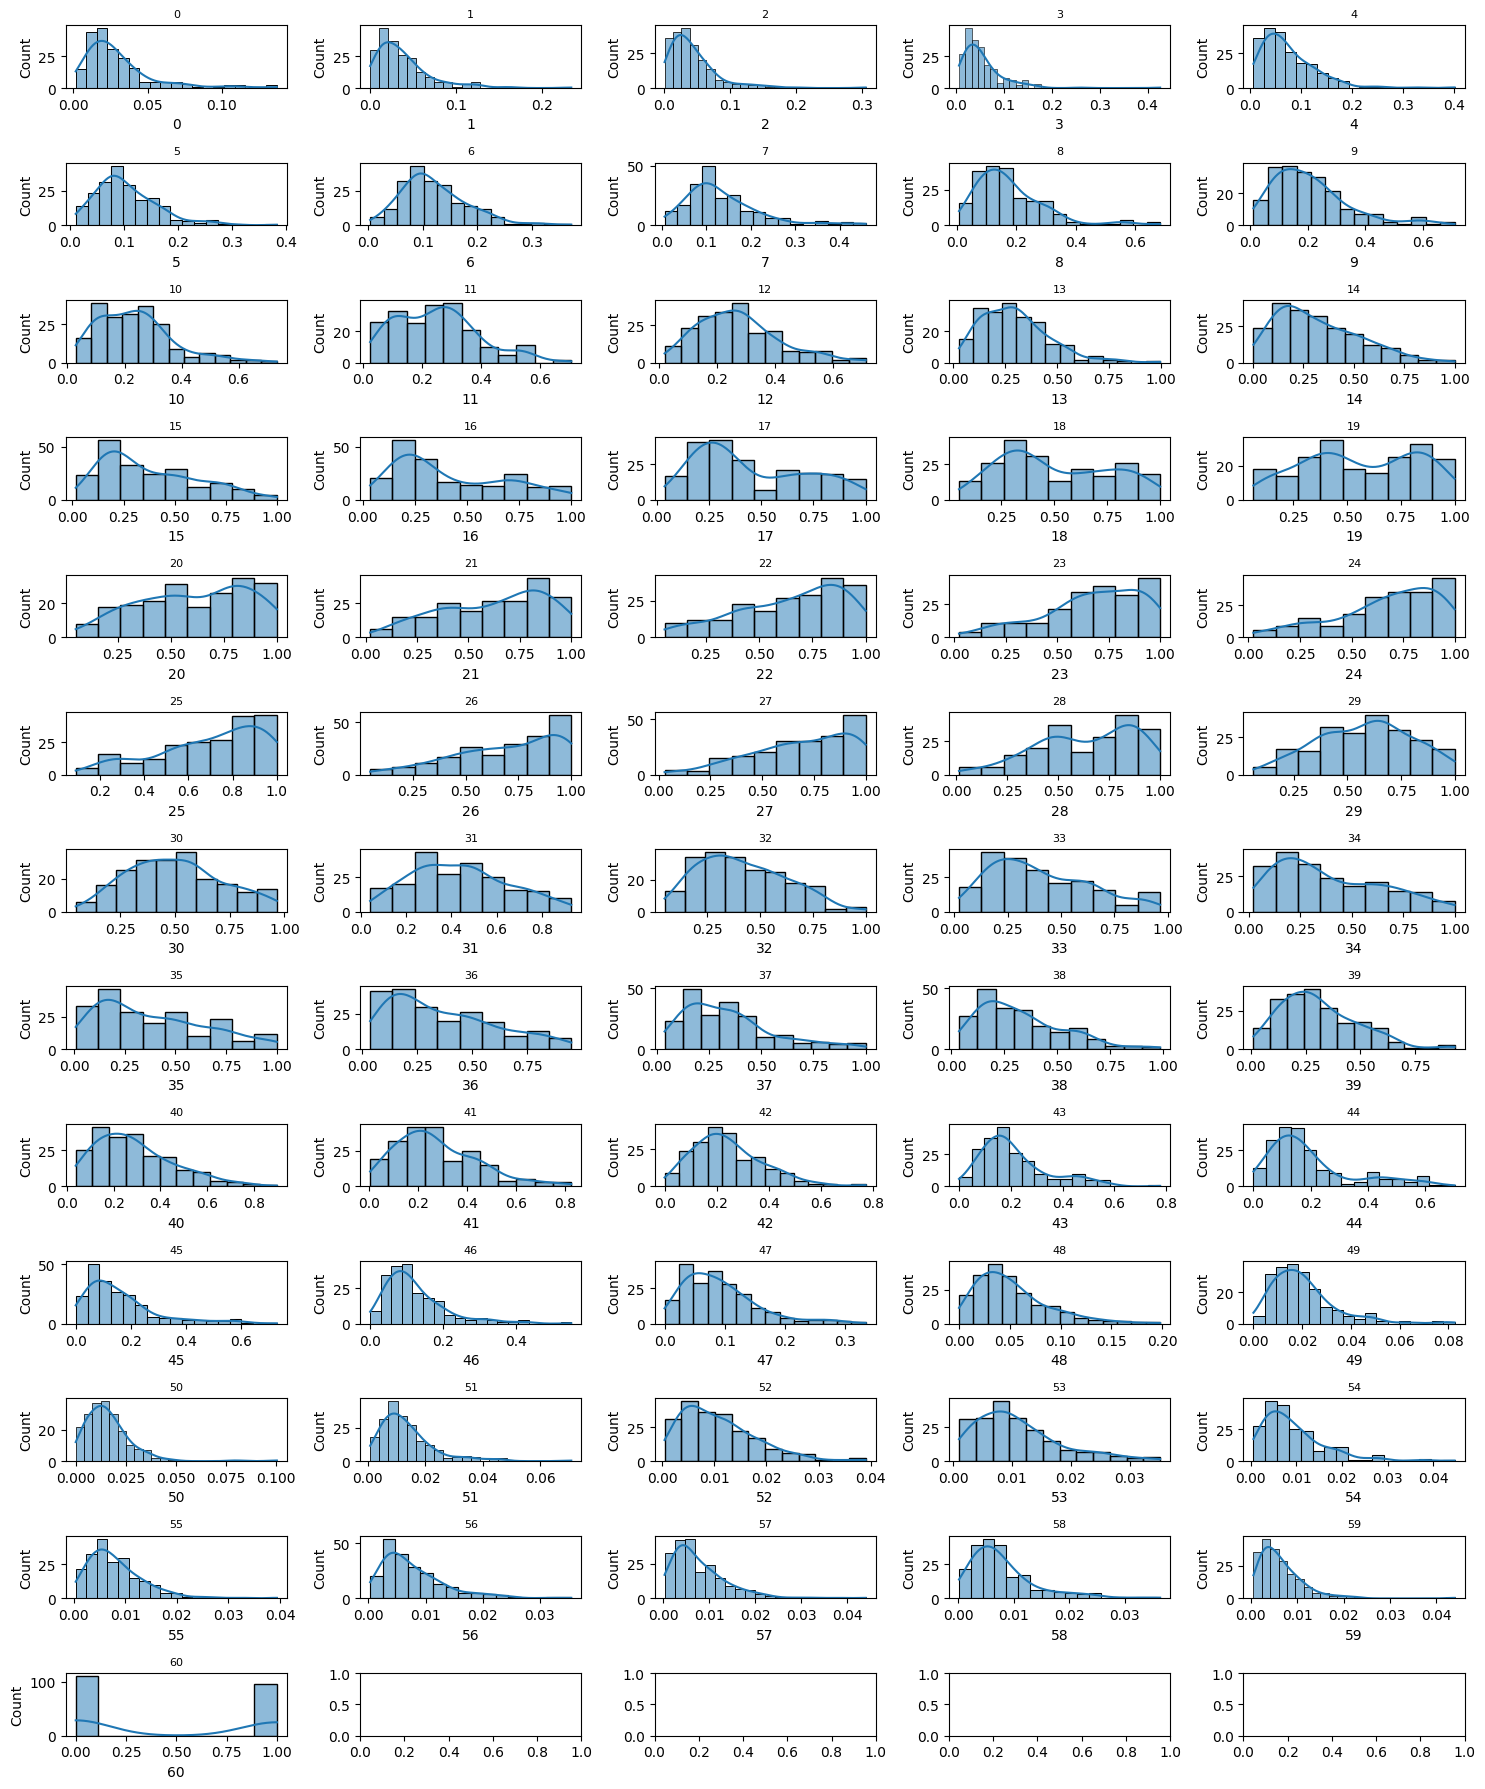

In [ ]:
fig , axes = plt.subplots(13 , 5 , figsize=(15 , 18))
axes = axes.flatten()


for i , col in enumerate(df.columns):
  sns.histplot(df[col] , kde = True , ax = axes[i])
  axes[i].set_title(col , fontsize = 8)

plt.tight_layout()
plt.show()



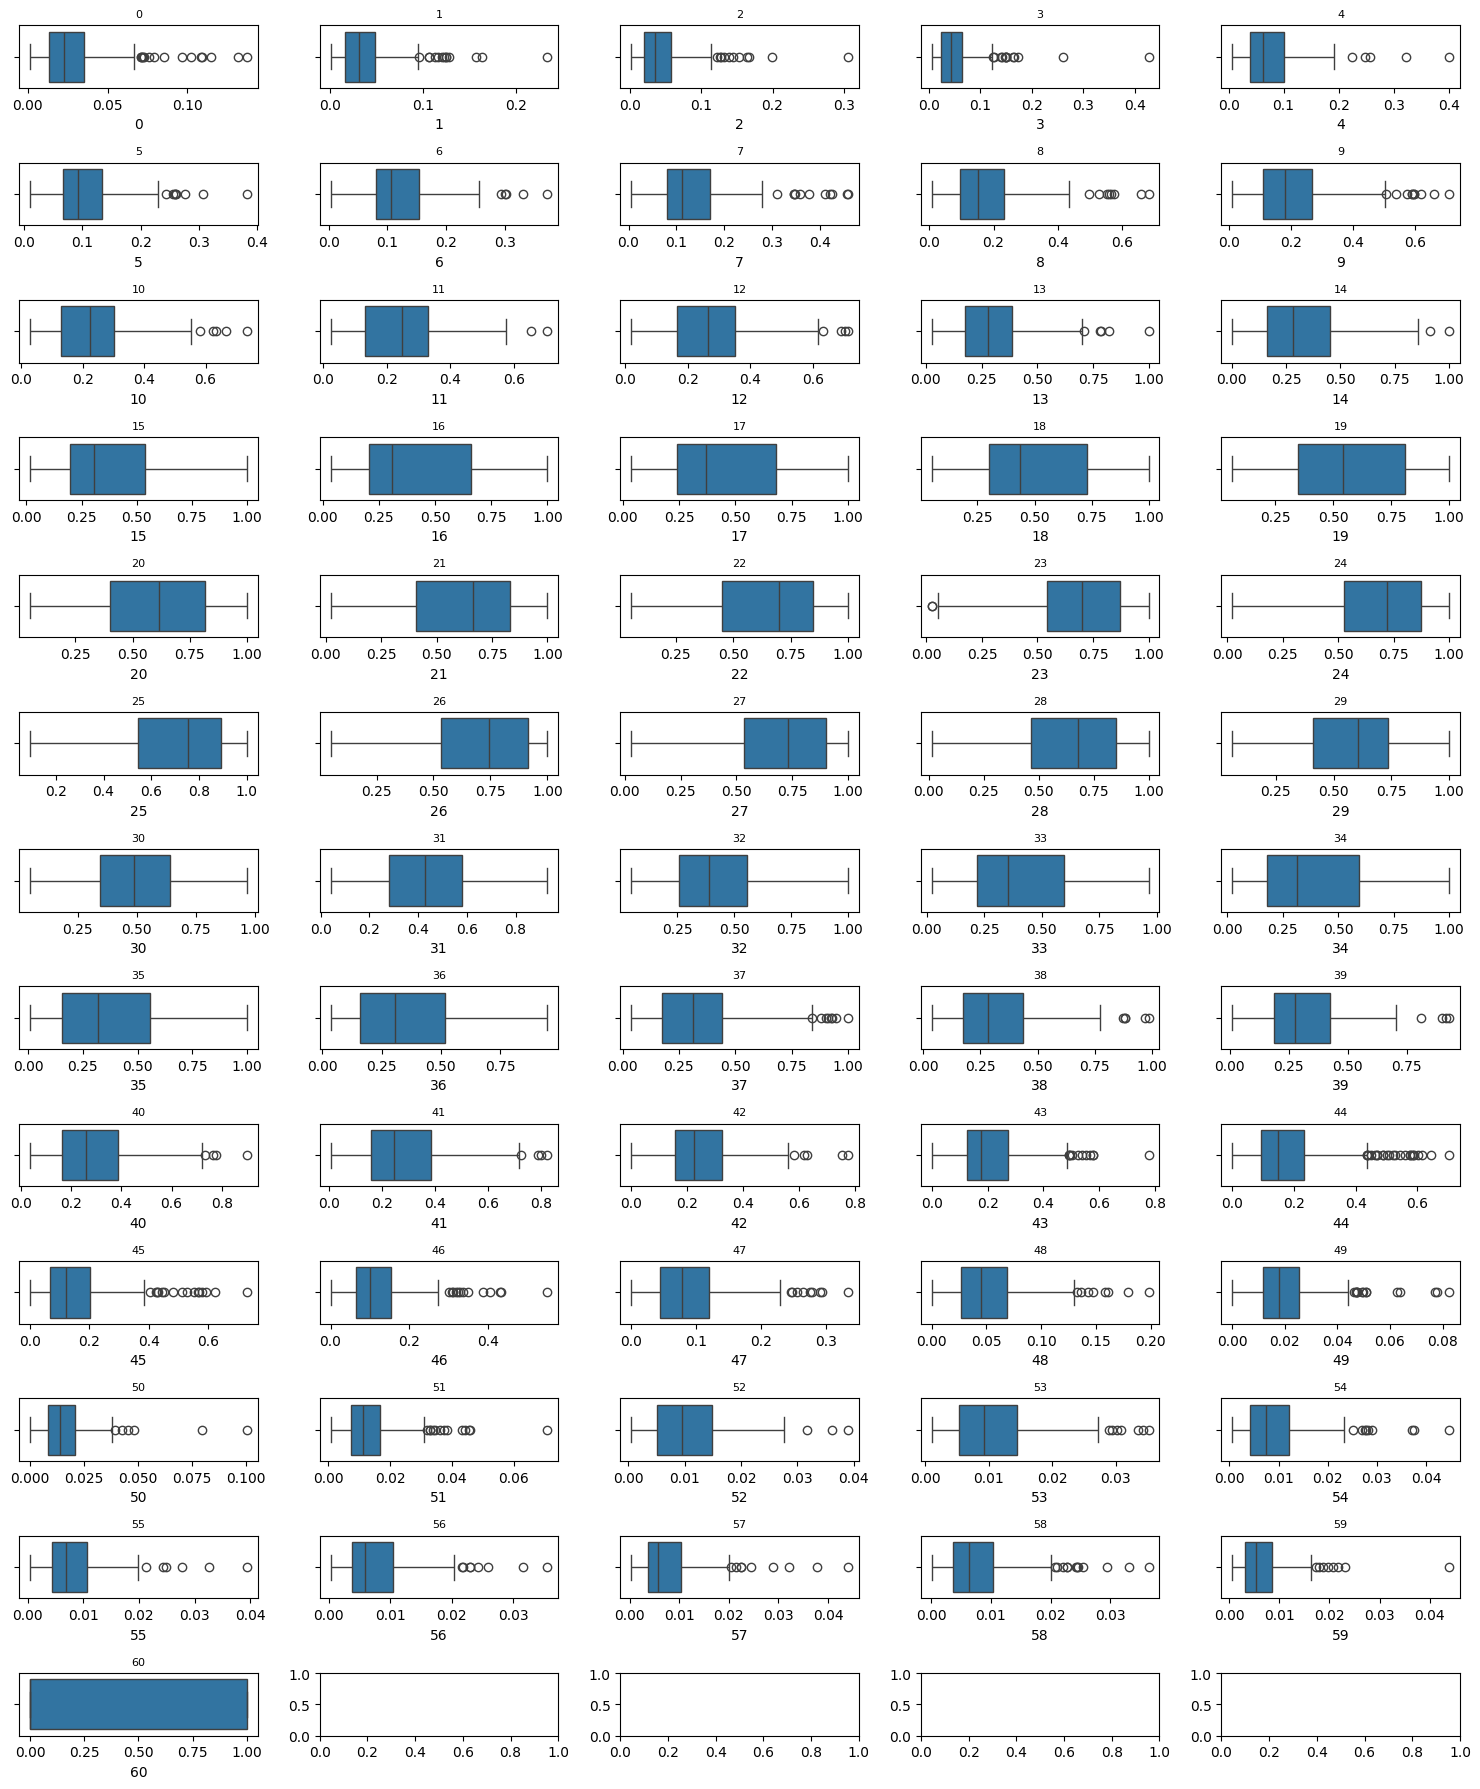

In [ ]:
fig , axes = plt.subplots(13 , 5 , figsize=(15 , 18))
axes = axes.flatten()


for i , col in enumerate(df.columns):
  sns.boxplot(x = df[col] ,ax = axes[i])
  axes[i].set_title(col , fontsize = 8)

plt.tight_layout()
plt.show()

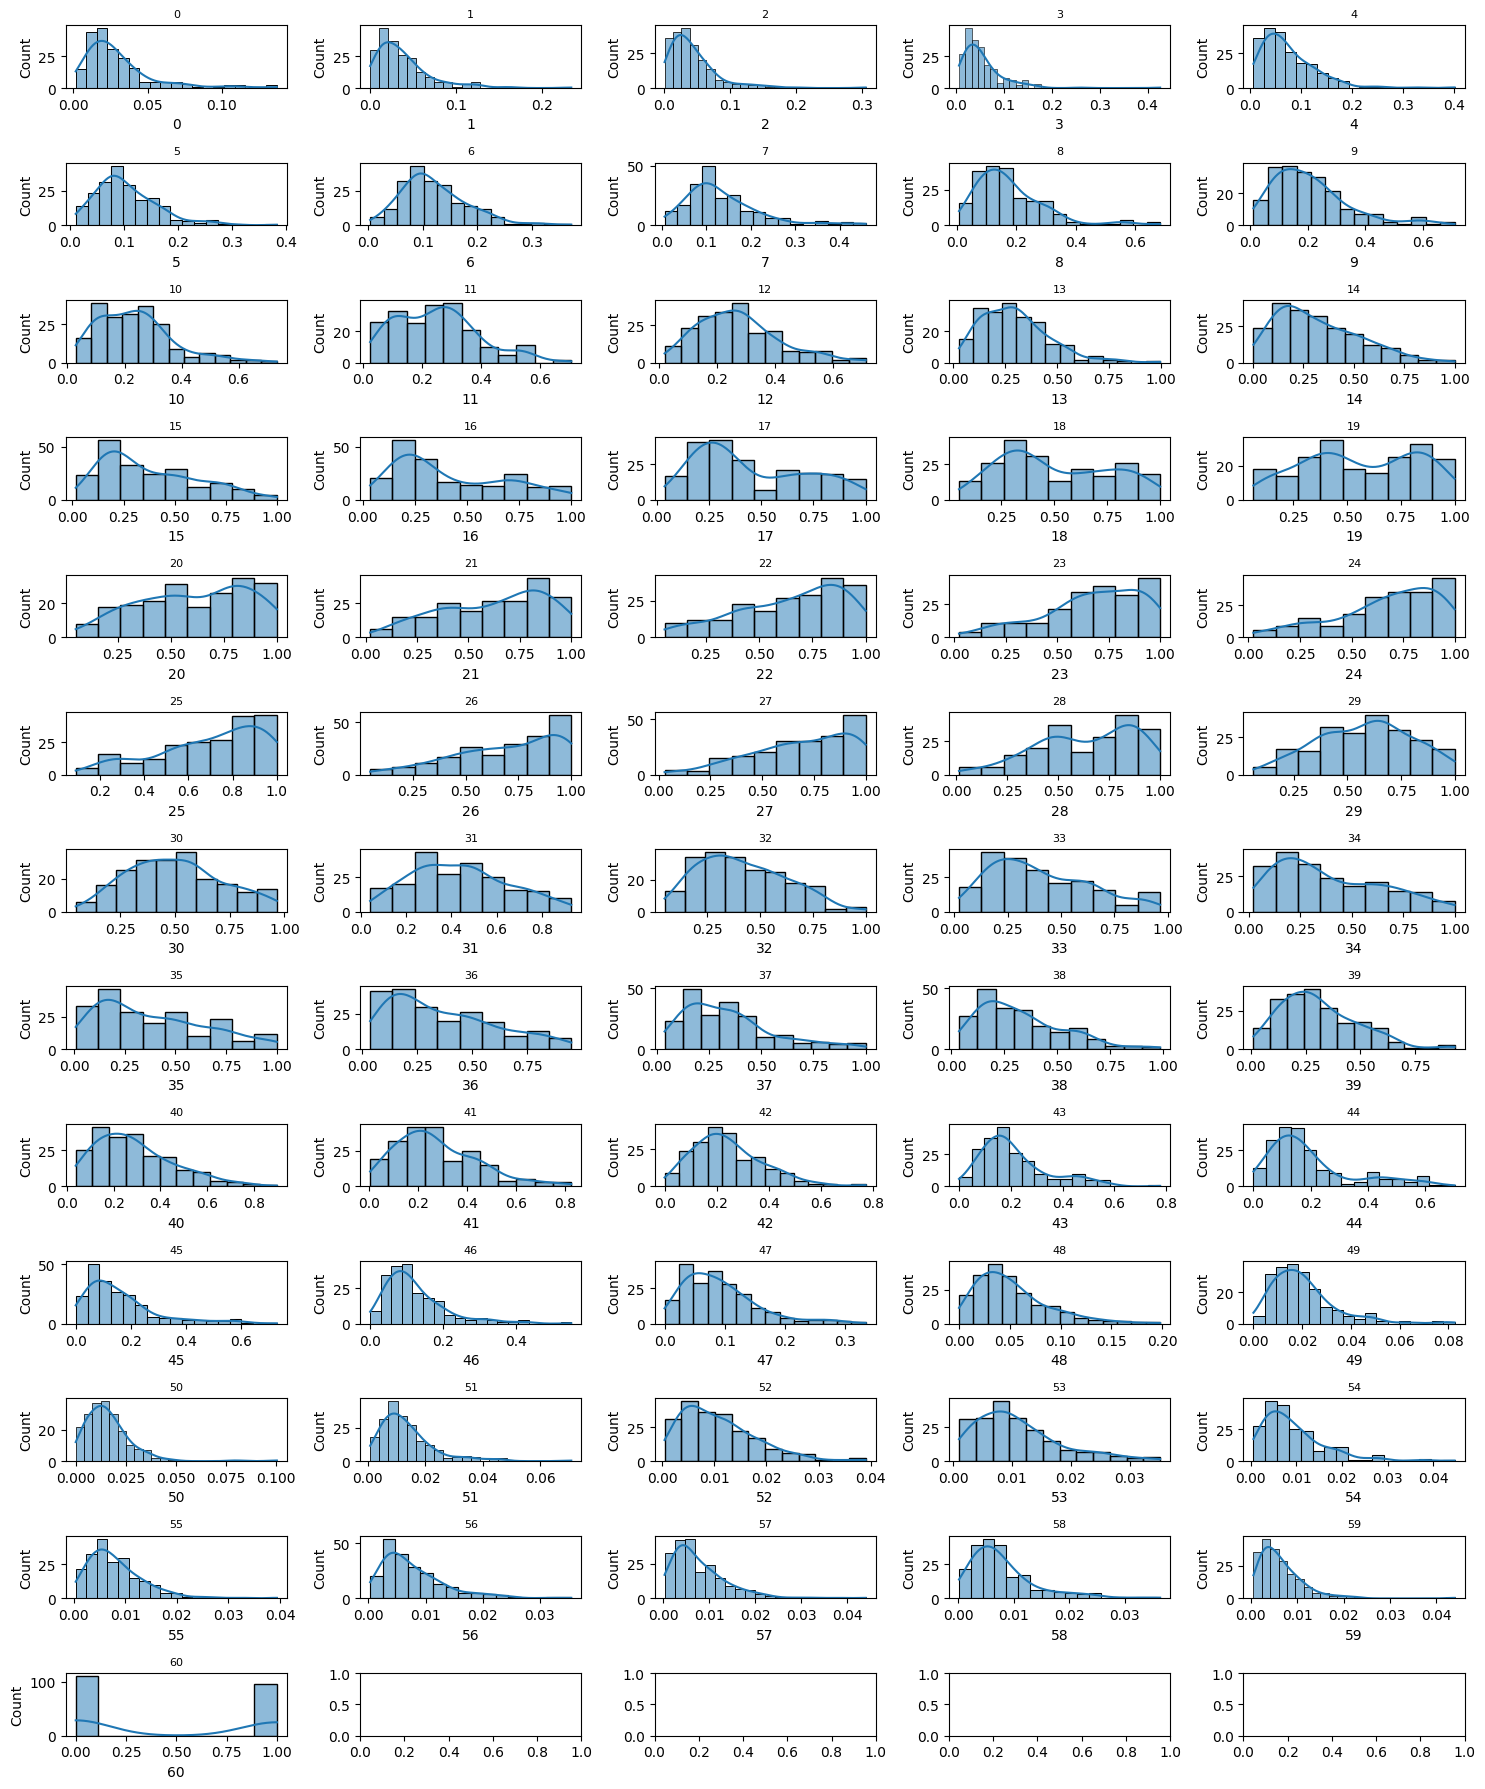

In [ ]:
fig , axes = plt.subplots(13 , 5 , figsize=(15 , 18))
axes = axes.flatten()

for i , col in enumerate(df.columns):
  sns.histplot(df[col] , kde = True , ax = axes[i])
  axes[i].set_title(col , fontsize = 8)

plt.tight_layout()
plt.show()

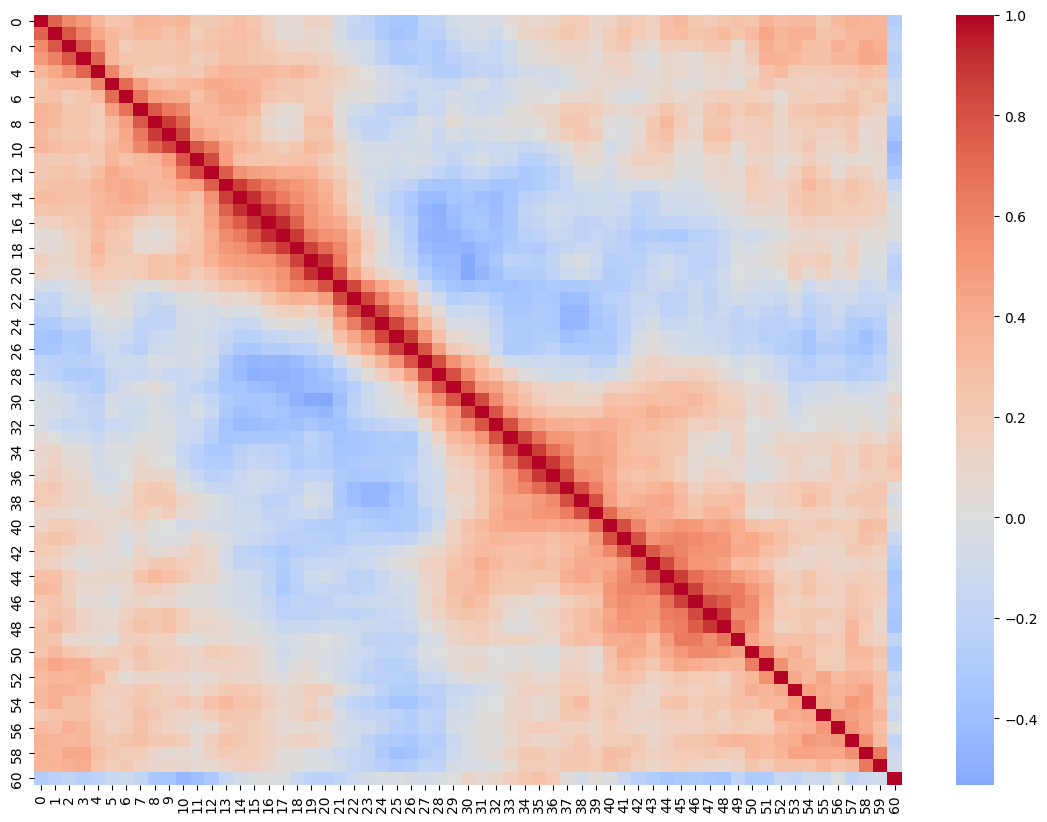

In [ ]:
plt.figure(figsize = (14 ,10))
sns.heatmap(
    df.corr(),
    cmap = "coolwarm",
    center = 0
)
plt.show()

In [ ]:
X = df.drop(columns = [60])
y = df[60]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = SVC()

In [ ]:
model.fit(X_train_scaled , y_train)

SVC()

In [ ]:
y_train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train , y_train_pred)
train_acc

0.9819277108433735

In [ ]:
y_test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test , y_test_pred)

In [ ]:
print(f"Training Accuracy : {round(train_acc*100 , 2)}%" )
print(f"Testing Accuracy : {round(test_acc*100 , 2)}%")

Training Accuracy : 98.19%
Testing Accuracy : 88.1%


In [ ]:
print(classification_report(y_test , y_test_pred))

              precision    recall  f1-score   support

           0       0.96      0.85      0.90        26
           1       0.79      0.94      0.86        16

    accuracy                           0.88        42
   macro avg       0.87      0.89      0.88        42
weighted avg       0.89      0.88      0.88        42



In [ ]:
def predictive_system(input_feature):
  scaled_feature = scaler.transform([input_feature])
  prediction = model.predict(scaled_feature)
  if(prediction == 1):
    print("Rock")
  else:
    print("Mine")


In [ ]:
X_test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59
161,0.0305,0.0363,0.0214,0.0227,0.0456,0.0665,0.0939,0.0972,0.2535,0.3127,0.2192,0.2621,0.2419,0.2179,0.1159,0.1237,0.0886,0.1755,0.1758,0.1540,0.0512,0.1805,0.4039,0.5697,0.6577,0.7474,0.8543,0.9085,0.8668,0.8892,0.9065,0.8522,0.7204,0.6200,0.6253,0.6848,0.7337,0.6281,0.5725,0.6119,0.5597,0.4965,0.5027,0.5772,0.5907,0.4803,0.3877,0.2779,0.1427,0.0424,0.0271,0.0200,0.0070,0.0070,0.0086,0.0089,0.0074,0.0042,0.0055,0.0021
15,0.0298,0.0615,0.0650,0.0921,0.1615,0.2294,0.2176,0.2033,0.1459,0.0852,0.2476,0.3645,0.2777,0.2826,0.3237,0.4335,0.5638,0.4555,0.4348,0.6433,0.3932,0.1989,0.3540,0.9165,0.9371,0.4620,0.2771,0.6613,0.8028,0.4200,0.5192,0.6962,0.5792,0.8889,0.7863,0.7133,0.7615,0.4401,0.3009,0.3163,0.2809,0.2898,0.0526,0.1867,0.1553,0.1633,0.1252,0.0748,0.0452,0.0064,0.0154,0.0031,0.0153,0.0071,0.0212,0.0076,0.0152,0.0049,0.0200,0.0073
73,0.0139,0.0222,0.0089,0.0108,0.0215,0.0136,0.0659,0.0954,0.0786,0.1015,0.1261,0.0828,0.0493,0.0848,0.1514,0.1396,0.1066,0.1923,0.2991,0.3247,0.3797,0.5658,0.7483,0.8757,0.9048,0.7511,0.6858,0.7043,0.5864,0.3773,0.2206,0.2628,0.2672,0.2907,0.1982,0.2288,0.3186,0.2871,0.2921,0.2806,0.2682,0.2112,0.1513,0.1789,0.1850,0.1717,0.0898,0.0656,0.0445,0.0110,0.0024,0.0062,0.0072,0.0113,0.0012,0.0022,0.0025,0.0059,0.0039,0.0048
96,0.0181,0.0146,0.0026,0.0141,0.0421,0.0473,0.0361,0.0741,0.1398,0.1045,0.0904,0.0671,0.0997,0.1056,0.0346,0.1231,0.1626,0.3652,0.3262,0.2995,0.2109,0.2104,0.2085,0.2282,0.0747,0.1969,0.4086,0.6385,0.7970,0.7508,0.5517,0.2214,0.4672,0.4479,0.2297,0.3235,0.4480,0.5581,0.6520,0.5354,0.2478,0.2268,0.1788,0.0898,0.0536,0.0374,0.0990,0.0956,0.0317,0.0142,0.0076,0.0223,0.0255,0.0145,0.0233,0.0041,0.0018,0.0048,0.0089,0.0085
166,0.0411,0.0277,0.0604,0.0525,0.0489,0.0385,0.0611,0.1117,0.1237,0.2300,0.1370,0.1335,0.2137,0.1526,0.0775,0.1196,0.0903,0.0689,0.2071,0.2975,0.2836,0.3353,0.3622,0.3202,0.3452,0.3562,0.3892,0.6622,0.9254,1.0000,0.8528,0.6297,0.5250,0.4012,0.2901,0.2007,0.3356,0.4799,0.6147,0.6246,0.4973,0.3492,0.2662,0.3137,0.4282,0.4262,0.3511,0.2458,0.1259,0.0327,0.0181,0.0217,0.0038,0.0019,0.0065,0.0132,0.0108,0.0050,0.0085,0.0044


In [ ]:
y_test.head()

,60
161,0
15,1
73,1
96,1
166,0


In [ ]:
test_1 = X_test.loc[161].tolist()
print(test_1)

[0.0305, 0.0363, 0.0214, 0.0227, 0.0456, 0.0665, 0.0939, 0.0972, 0.2535, 0.3127, 0.2192, 0.2621, 0.2419, 0.2179, 0.1159, 0.1237, 0.0886, 0.1755, 0.1758, 0.154, 0.0512, 0.1805, 0.4039, 0.5697, 0.6577, 0.7474, 0.8543, 0.9085, 0.8668, 0.8892, 0.9065, 0.8522, 0.7204, 0.62, 0.6253, 0.6848, 0.7337, 0.6281, 0.5725, 0.6119, 0.5597, 0.4965, 0.5027, 0.5772, 0.5907, 0.4803, 0.3877, 0.2779, 0.1427, 0.0424, 0.0271, 0.02, 0.007, 0.007, 0.0086, 0.0089, 0.0074, 0.0042, 0.0055, 0.0021]


In [ ]:
predictive_system(test_1)

Mine
